# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI Impatct On Jobs Dataset](https://www.kaggle.com/datasets/dreamtensor/ai-impact-on-jobs-2030)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('AI_Impact_on_Jobs_2030.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


## last Five row

In [4]:
df.tail()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
2995,Doctor,111319,6,Bachelor's,0.24,1.18,0.20,Low,0.73,0.37,0.99,0.07,0.08,0.92,0.65,0.33,0.76,0.45
2996,UX Researcher,44363,29,PhD,0.65,0.74,0.35,Medium,0.23,0.48,0.05,0.88,0.56,0.29,0.69,0.80,0.61,0.20
2997,Data Scientist,61325,23,Master's,0.64,0.94,0.39,Medium,0.28,0.62,0.73,0.21,0.96,0.01,0.70,0.29,0.48,0.57
2998,Graphic Designer,110296,7,PhD,0.95,1.23,0.46,Medium,0.21,0.18,0.14,0.22,0.55,0.68,0.31,0.55,0.34,0.70
2999,Graphic Designer,123909,25,PhD,0.69,0.56,0.49,Medium,0.77,0.54,0.95,0.05,0.29,0.22,0.77,0.52,0.14,0.29


## Shape of our dataset

In [5]:
df.shape

(3000, 18)

## List out all columns

In [6]:
df.columns

Index(['Job_Title', 'Average_Salary', 'Years_Experience', 'Education_Level',
       'AI_Exposure_Index', 'Tech_Growth_Factor',
       'Automation_Probability_2030', 'Risk_Category', 'Skill_1', 'Skill_2',
       'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8',
       'Skill_9', 'Skill_10'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Job_Title                       object
Average_Salary                   int64
Years_Experience                 int64
Education_Level                 object
AI_Exposure_Index              float64
Tech_Growth_Factor             float64
Automation_Probability_2030    float64
Risk_Category                   object
Skill_1                        float64
Skill_2                        float64
Skill_3                        float64
Skill_4                        float64
Skill_5                        float64
Skill_6                        float64
Skill_7                        float64
Skill_8                        float64
Skill_9                        float64
Skill_10                       float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

## Check Null Value

In [9]:
df.isnull().sum()

Job_Title                      0
Average_Salary                 0
Years_Experience               0
Education_Level                0
AI_Exposure_Index              0
Tech_Growth_Factor             0
Automation_Probability_2030    0
Risk_Category                  0
Skill_1                        0
Skill_2                        0
Skill_3                        0
Skill_4                        0
Skill_5                        0
Skill_6                        0
Skill_7                        0
Skill_8                        0
Skill_9                        0
Skill_10                       0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.995343,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,34608.088767,8.739788,0.284004,0.287669,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,30030.000000,0.000000,0.000000,0.500000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58640.000000,7.000000,0.260000,0.740000,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,119086.500000,22.000000,0.740000,1.240000,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000
max,149798.000000,29.000000,1.000000,1.500000,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

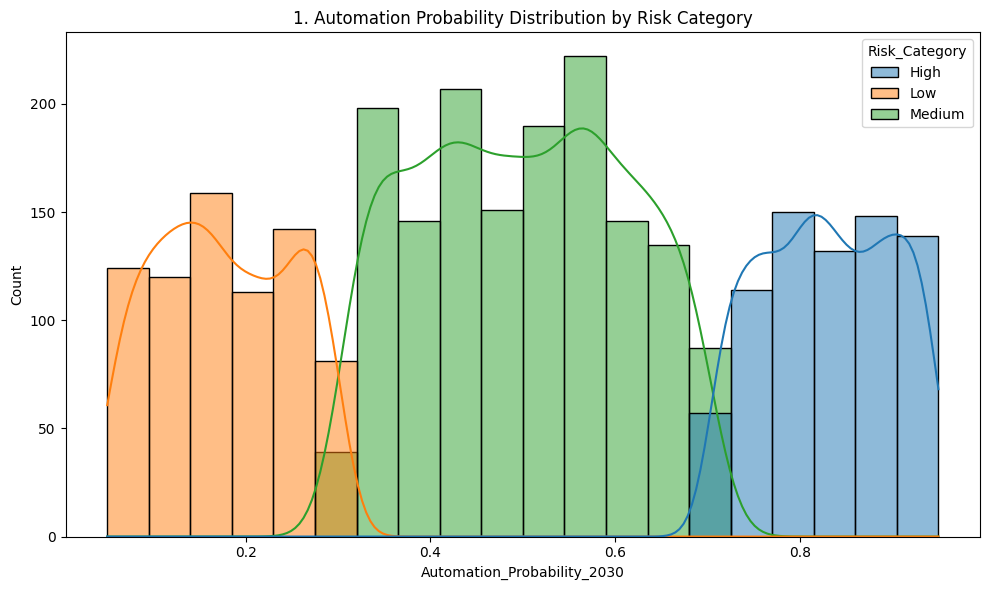

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Automation_Probability_2030', hue='Risk_Category', bins=20, kde=True)
plt.title(f'{plot_no}. Automation Probability Distribution by Risk Category')
show_fig()
plot_no += 1

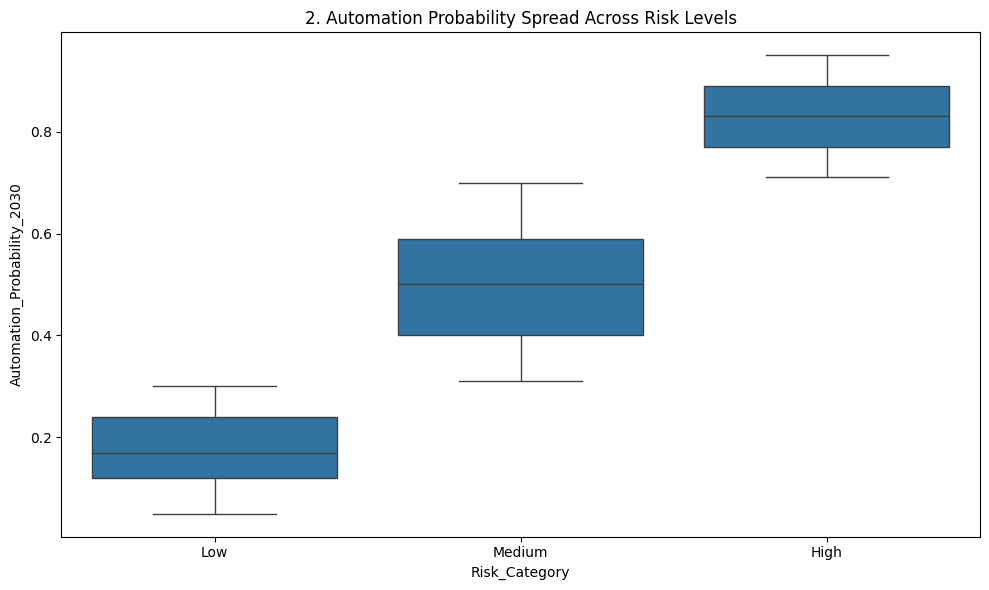

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Risk_Category', y='Automation_Probability_2030', order=['Low', 'Medium', 'High'])
plt.title(f'{plot_no}. Automation Probability Spread Across Risk Levels')
show_fig()
plot_no += 1

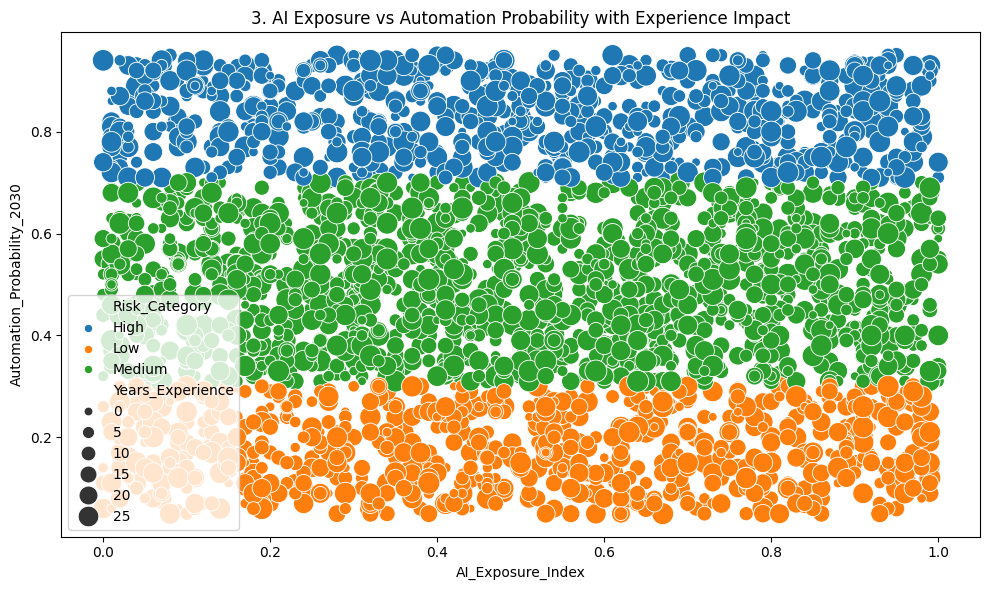

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AI_Exposure_Index', y='Automation_Probability_2030', hue='Risk_Category', size='Years_Experience', sizes=(40, 250))
plt.title(f'{plot_no}. AI Exposure vs Automation Probability with Experience Impact')
show_fig()
plot_no += 1

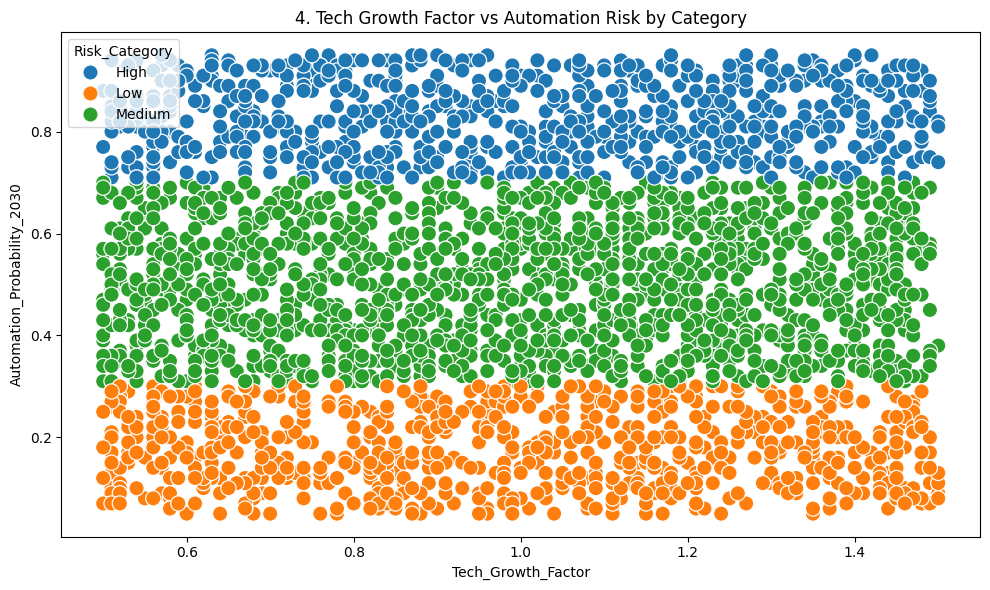

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Tech_Growth_Factor', y='Automation_Probability_2030', hue='Risk_Category', s=120)
plt.title(f'{plot_no}. Tech Growth Factor vs Automation Risk by Category')
show_fig()
plot_no += 1

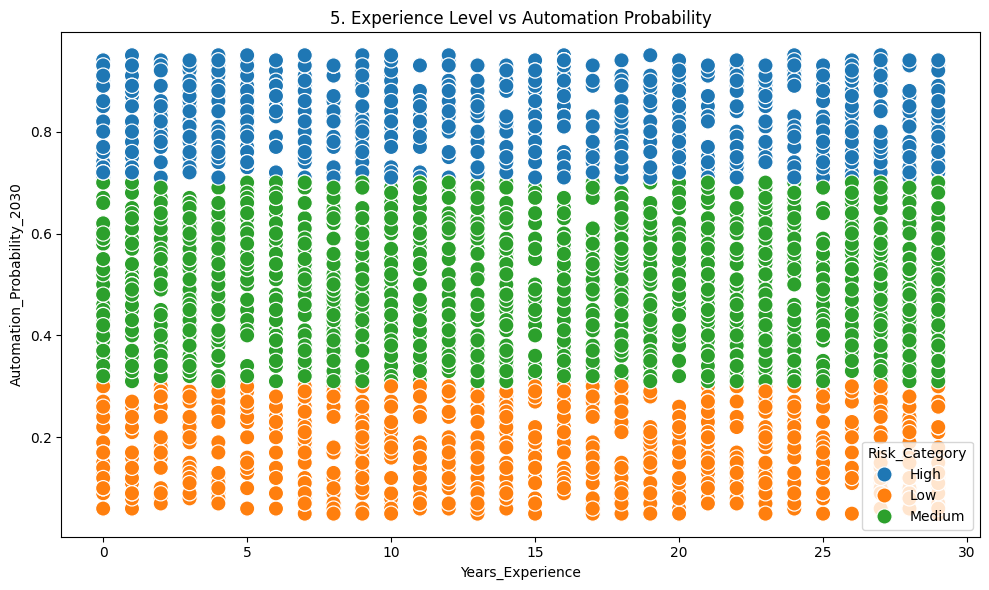

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Years_Experience', y='Automation_Probability_2030', hue='Risk_Category', s=120)
plt.title(f'{plot_no}. Experience Level vs Automation Probability')
show_fig()
plot_no += 1

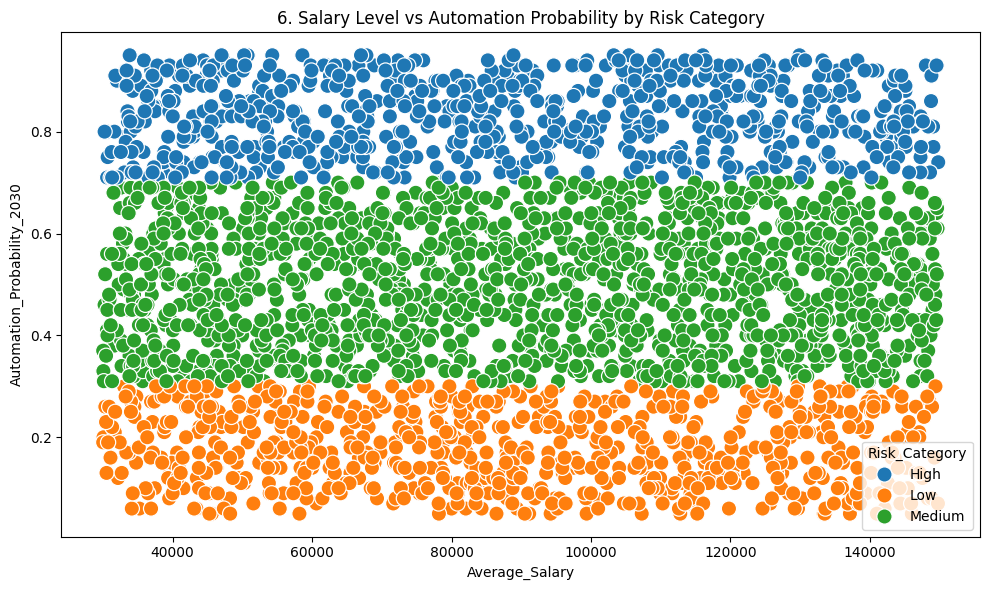

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Average_Salary', y='Automation_Probability_2030', hue='Risk_Category', s=120)
plt.title(f'{plot_no}. Salary Level vs Automation Probability by Risk Category')
show_fig()
plot_no += 1

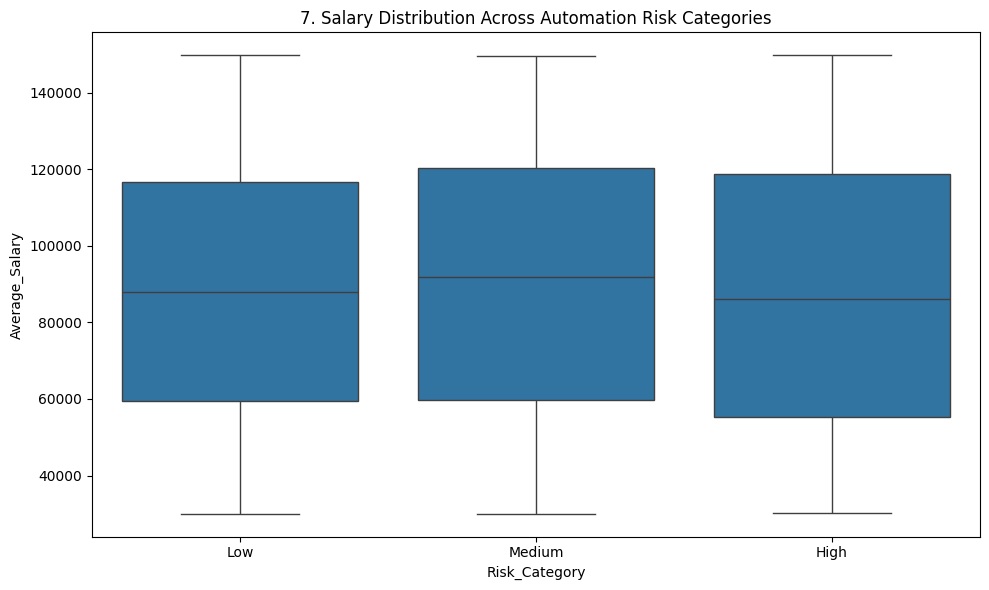

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Risk_Category', y='Average_Salary', order=['Low', 'Medium', 'High'])
plt.title(f'{plot_no}. Salary Distribution Across Automation Risk Categories')
show_fig()
plot_no += 1

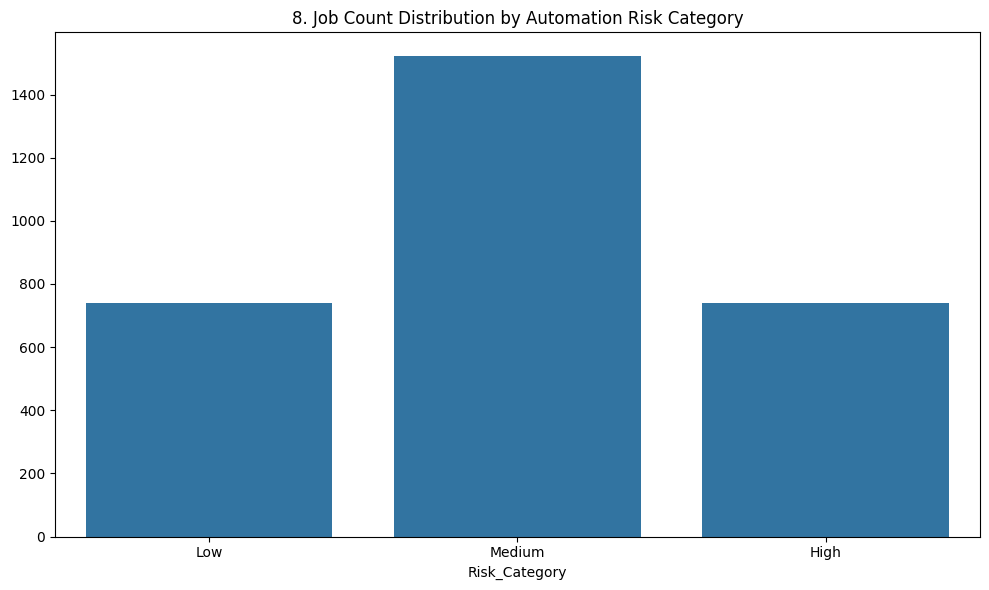

In [20]:
fig = plt.figure(figsize=(10,6))
risk_counts = df['Risk_Category'].value_counts().reindex(['Low', 'Medium', 'High'])
sns.barplot(x=risk_counts.index, y=risk_counts.values)
plt.title(f'{plot_no}. Job Count Distribution by Automation Risk Category')
show_fig()
plot_no += 1

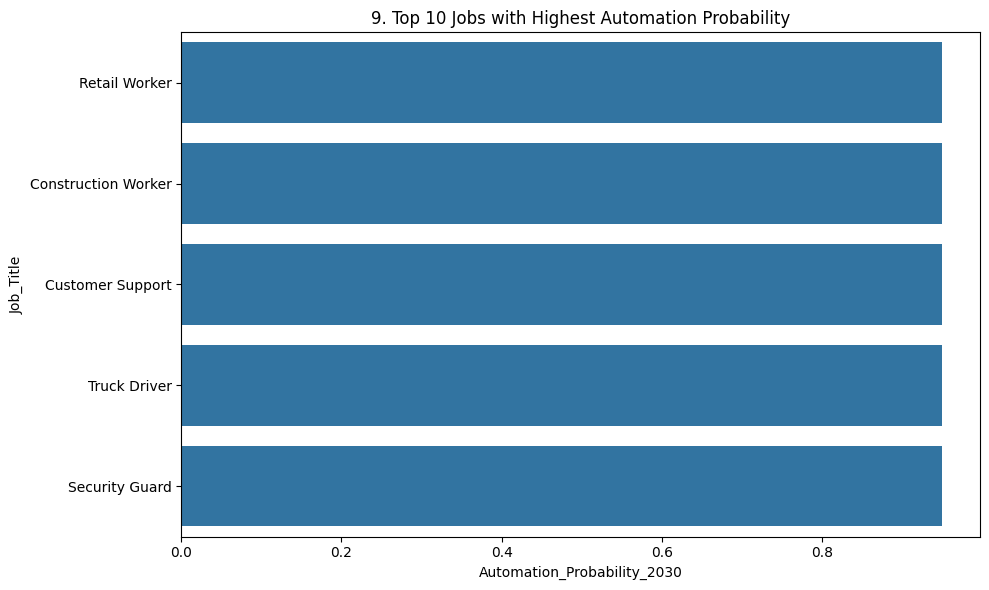

In [21]:
fig = plt.figure(figsize=(10,6))
top_risk_jobs = df.sort_values('Automation_Probability_2030', ascending=False).head(10)
sns.barplot(data=top_risk_jobs, x='Automation_Probability_2030', y='Job_Title')
plt.title(f'{plot_no}. Top 10 Jobs with Highest Automation Probability')
show_fig()
plot_no += 1

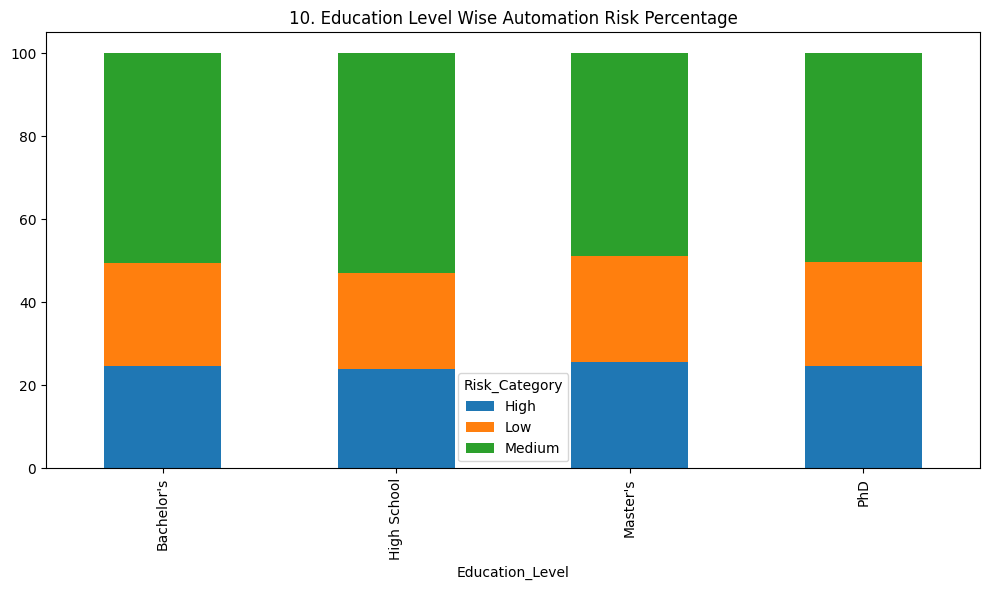

In [22]:
fig = plt.figure(figsize=(10,6))
education_risk = pd.crosstab(df['Education_Level'], df['Risk_Category'], normalize='index') * 100
education_risk.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Education Level Wise Automation Risk Percentage')
show_fig()
plot_no += 1

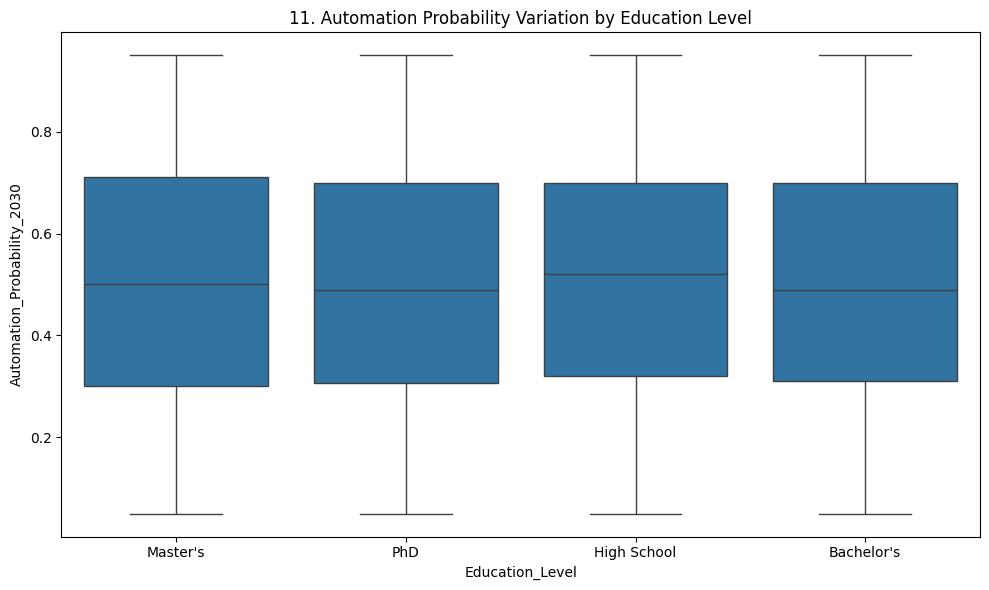

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Education_Level', y='Automation_Probability_2030')
plt.title(f'{plot_no}. Automation Probability Variation by Education Level')
show_fig()
plot_no += 1

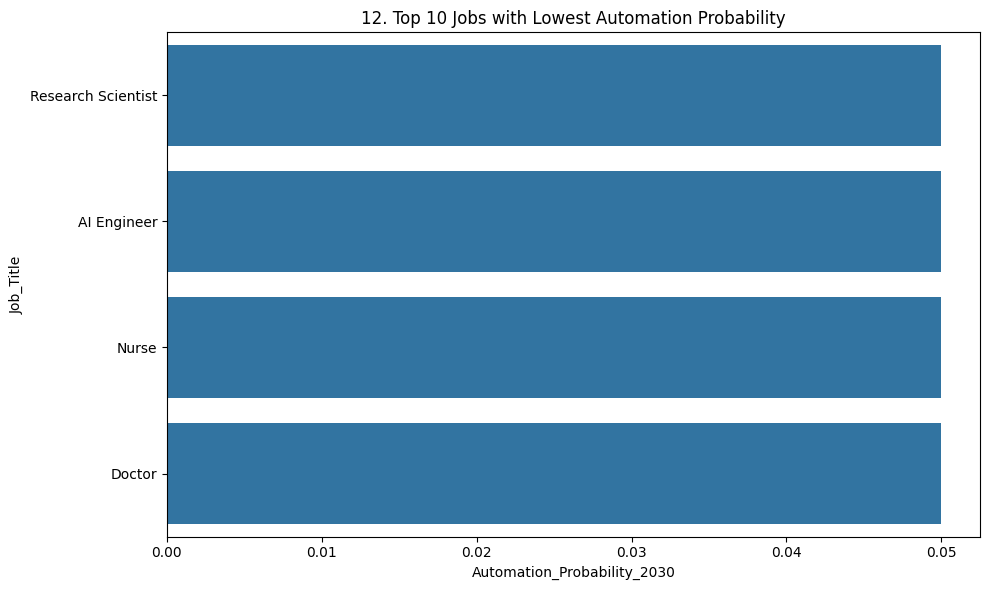

In [24]:
fig = plt.figure(figsize=(10,6))
low_risk_jobs = df.sort_values('Automation_Probability_2030', ascending=True).head(10)
sns.barplot(data=low_risk_jobs, x='Automation_Probability_2030', y='Job_Title')
plt.title(f'{plot_no}. Top 10 Jobs with Lowest Automation Probability')
show_fig()
plot_no += 1

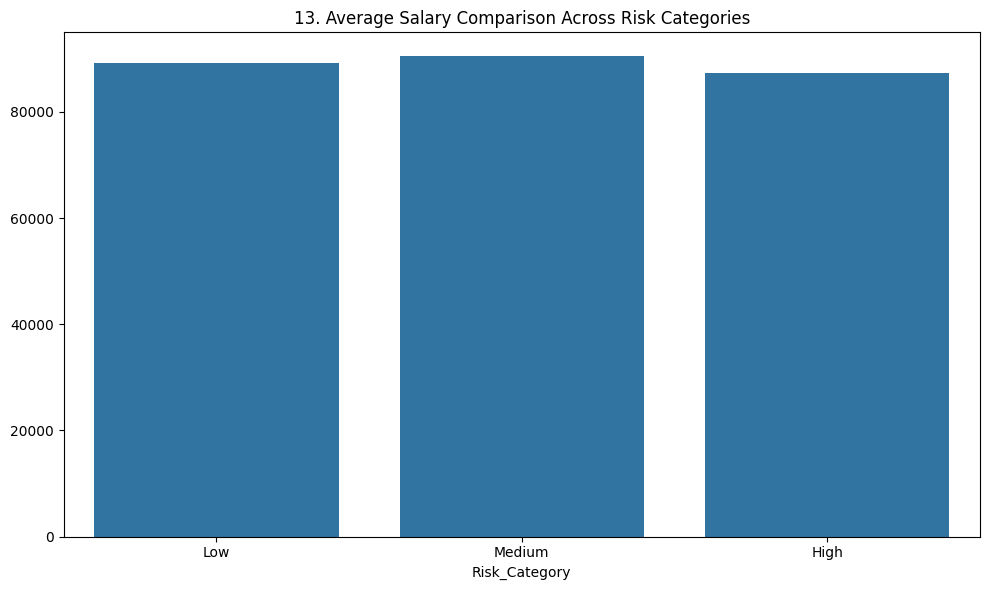

In [25]:
fig = plt.figure(figsize=(10,6))
salary_risk = df.groupby('Risk_Category')['Average_Salary'].mean().reindex(['Low', 'Medium', 'High'])
sns.barplot(x=salary_risk.index, y=salary_risk.values)
plt.title(f'{plot_no}. Average Salary Comparison Across Risk Categories')
show_fig()
plot_no += 1

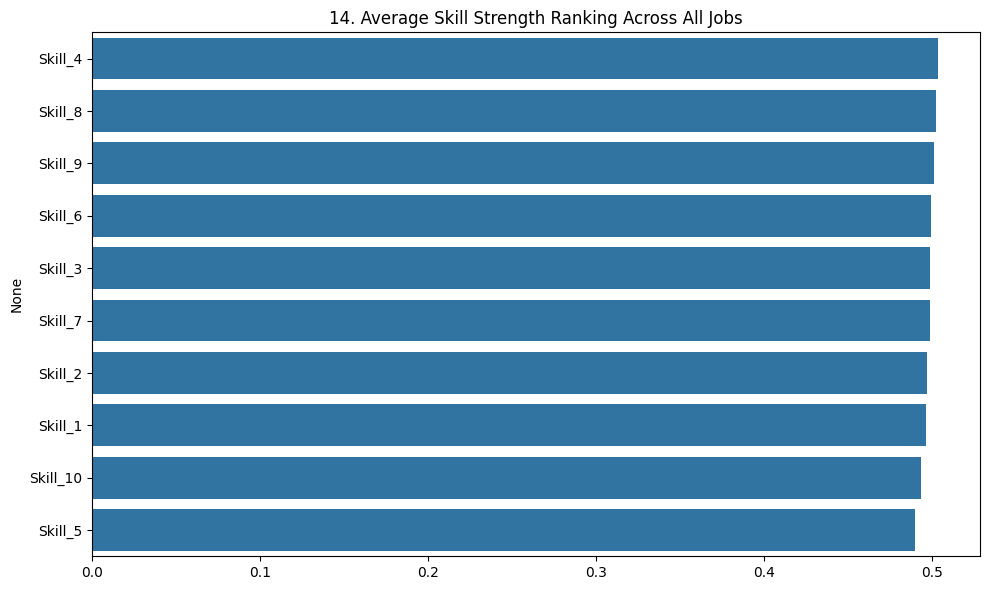

In [26]:
fig = plt.figure(figsize=(10,6))
skill_cols = [col for col in df.columns if col.startswith('Skill_')]
skill_avg = df[skill_cols].mean().sort_values(ascending=False)
sns.barplot(x=skill_avg.values, y=skill_avg.index)
plt.title(f'{plot_no}. Average Skill Strength Ranking Across All Jobs')
show_fig()
plot_no += 1

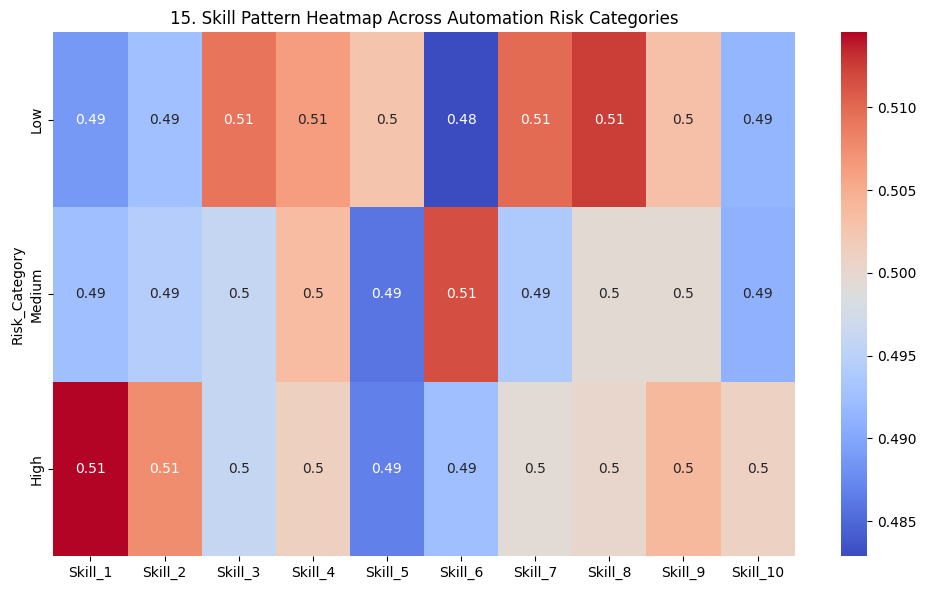

In [27]:
fig = plt.figure(figsize=(10,6))
skill_risk_avg = df.groupby('Risk_Category')[skill_cols].mean().reindex(['Low', 'Medium', 'High'])
sns.heatmap(skill_risk_avg, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Skill Pattern Heatmap Across Automation Risk Categories')
show_fig()
plot_no += 1

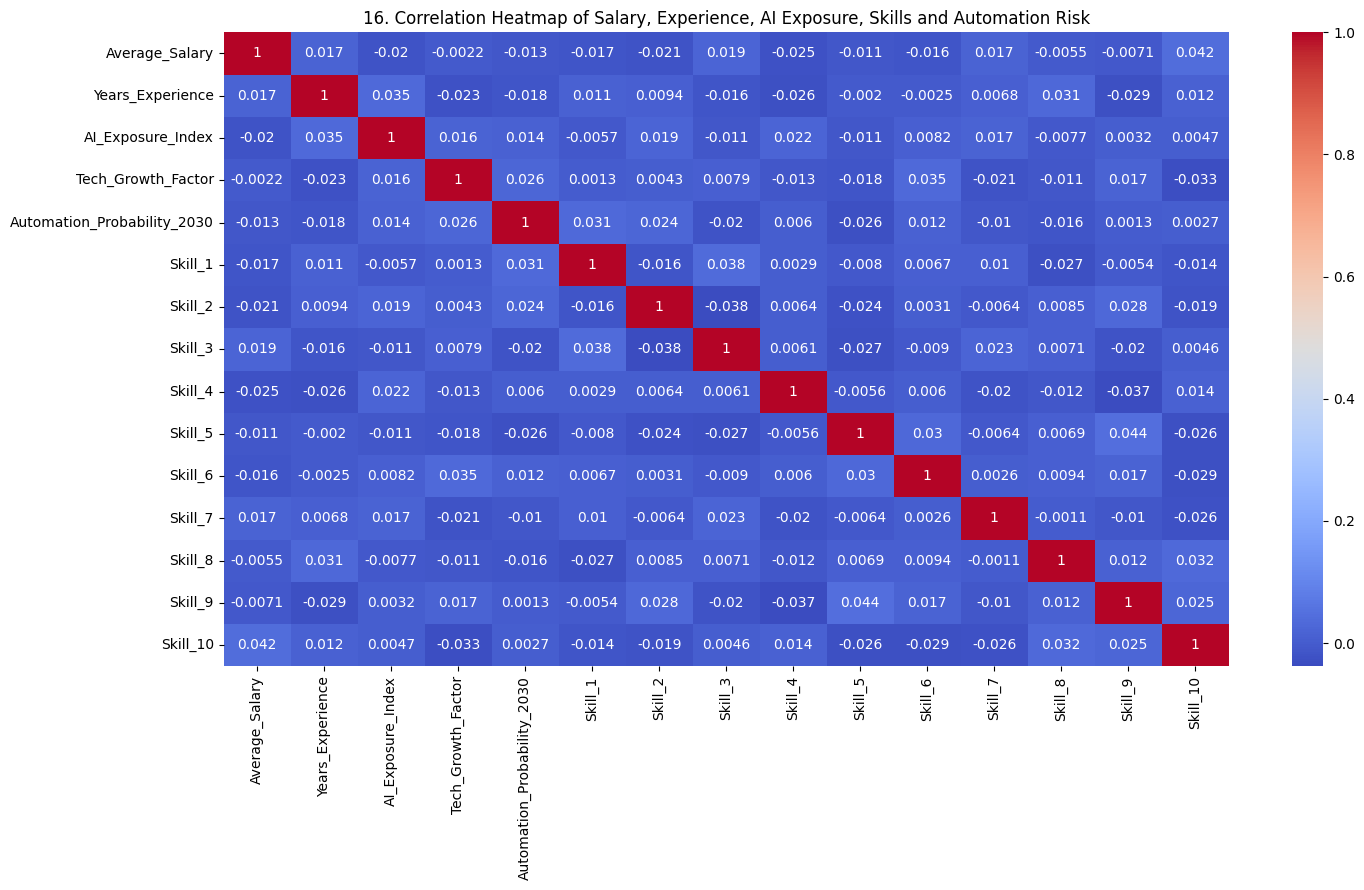

In [28]:
fig = plt.figure(figsize=(15, 9))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Salary, Experience, AI Exposure, Skills and Automation Risk')
show_fig()
plot_no += 1

# Model Training

## Select target column

In [29]:
target = "Risk_Category"

## Create X and y

In [30]:
X = df.drop(columns=[target])
y = df[target]

## Split numerical and categorical columns

In [31]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

## Create preprocessing pipeline

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

## Create SVM model pipeline

In [33]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=42))
    ]
)

## Train test split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train model

In [35]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict test data

In [36]:
y_pred = model.predict(X_test)

## Print accuracy score

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9933333333333333


## Print classification report

In [38]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



## Plot confusion matrix

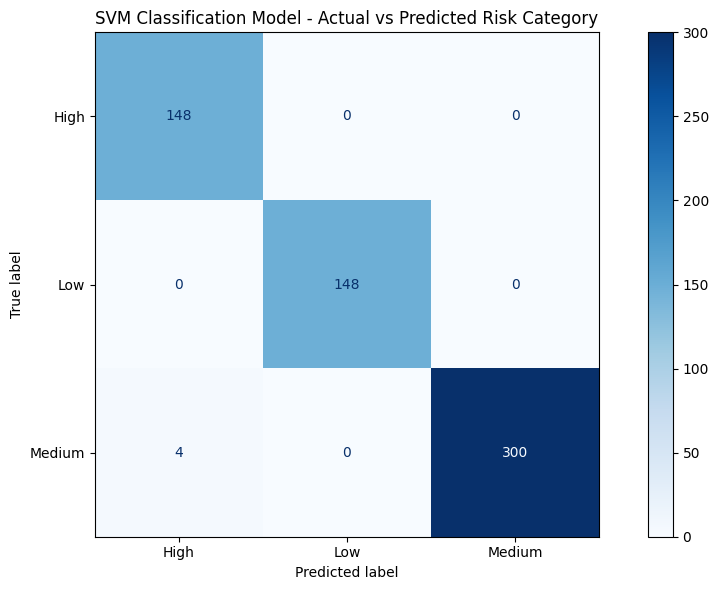

In [39]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", ax=plt.gca())
plt.title("SVM Classification Model - Actual vs Predicted Risk Category")
plt.tight_layout()
plt.show()